# 👩‍💻 **Explore Cross-Modal Embeddings with CLIP**

**Time Estimate:** 45 minutes

## 📋 **Overview**

In this activity, you will explore the capabilities of CLIP, a vision-language model developed by OpenAI. CLIP utilizes cross-modal embeddings to align text and images in a unified latent space, improving AI's understanding and processing of different modalities. You will compute similarity scores and visualize results to understand how CLIP bridges the gap between language and vision.

This understanding is crucial for roles involving AI development or research, as cross-modal embeddings are foundational to many applications in image recognition and natural language processing.

## 🎯 **Learning Outcomes**

By the end of this lab, you will be able to:

- Load and use the CLIP model to process text and images.
- Compute and visualize similarity scores between text descriptions and images.
- Reflect on the alignment of cross-modal embeddings in CLIP.

## Task 1: Load and Inspect the CLIP Model [15 minutes]

In [1]:
# imports
from transformers import CLIPProcessor, CLIPModel
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

1. Use Hugging Face's transformers library to initialize the CLIP model and processor.
2. Load an example image and select a few descriptive captions to act as your primary data for exploring the model's embedding capabilities.
3. Ensure your image is varied enough to challenge the description alignment.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded successfully!
Model has 151277313 parameters


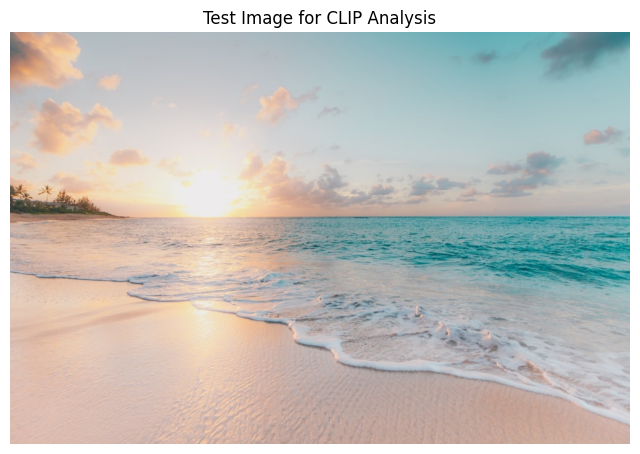


Testing with 6 different captions:
1. A sunny day at the beach
2. A cat sitting on a sofa
3. A bustling downtown street
4. Ocean waves on tropical shore
5. People enjoying outdoor activities
6. A snowy mountain landscape


In [2]:
# Task 1
# your code here...

# Load the CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

print("CLIP model loaded successfully!")
print(f"Model has {sum(p.numel() for p in clip_model.parameters())} parameters")

# Load an example image (using a sample from the web)
# For demonstration, we'll use a beach image
url = "https://images.unsplash.com/photo-1507525428034-b723cf961d3e?ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D&auto=format&fit=crop&w=1000&q=80"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title('Test Image for CLIP Analysis')
plt.show()

# Define descriptive captions with varying relevance
captions = [
    "A sunny day at the beach",
    "A cat sitting on a sofa",
    "A bustling downtown street",
    "Ocean waves on tropical shore",
    "People enjoying outdoor activities",
    "A snowy mountain landscape"
]

print(f"\nTesting with {len(captions)} different captions:")
for i, caption in enumerate(captions):
    print(f"{i+1}. {caption}")

🔍 **Practice**

Examine the CLIP model and processor setup. Consider:

- How the model architecture handles both text and image inputs.
- The variety of your chosen captions and how they relate to the image.

✅ **Success Checklist**

- Model and processor initialized correctly.
- Example image loaded successfully.
- Descriptive captions selected that provide good context for testing similarity.

💡 **Key Points**

- CLIP uses a transformer architecture for both text and vision encoders.
- The processor handles tokenization and image preprocessing automatically.
- Good caption variety is essential for meaningful similarity comparisons.

❗ **Common Mistakes to Avoid**

- Not initializing the processor alongside the model.
- Choosing non-descriptive captions that don't provide good context for divergence in similarity scores.
- Using images that are too simple or ambiguous for testing.

## Task 2: Encode and Process Inputs [15 minutes]
Encode the image and each caption using the CLIP processor.
1. Transform both data types into a shared vector space using the processor.
2. Ensure proper tensor formatting for model inference.
3. Verify that inputs are properly encoded and aligned for comparison.

In [3]:
# Task 2
# your code here...

# Encode inputs using CLIP processor
inputs = clip_processor(text=captions, images=image, return_tensors="pt", padding=True)

print("Input encoding successful!")
print(f"Text input shape: {inputs['input_ids'].shape}")
print(f"Image input shape: {inputs['pixel_values'].shape}")
print(f"Attention mask shape: {inputs['attention_mask'].shape}")

# Verify the encoding worked correctly
print(f"\nNumber of captions processed: {len(captions)}")
print(f"Batch size in tensors: {inputs['input_ids'].shape[0]}")
print(f"Image batch size: {inputs['pixel_values'].shape[0]}")

# Show first few tokens of the first caption
first_caption_tokens = inputs['input_ids'][0][:10]
print(f"\nFirst 10 tokens of first caption: {first_caption_tokens}")

Input encoding successful!
Text input shape: torch.Size([6, 8])
Image input shape: torch.Size([1, 3, 224, 224])
Attention mask shape: torch.Size([6, 8])

Number of captions processed: 6
Batch size in tensors: 6
Image batch size: 1

First 10 tokens of first caption: tensor([49406,   320,  5438,   575,   536,   518,  2117, 49407])


🔍 **Practice**

Reflect on the encoding process:

- How the processor handles different input modalities simultaneously.
- The structure of the encoded tensors and their dimensions.

✅ **Success Checklist**

- Inputs encoded successfully using the CLIP processor.
- Proper tensor formatting achieved for model inference.
- Text and image data aligned within the same processing batch.

💡 **Key Points**

- The processor ensures both modalities are transformed into compatible formats.
- Encoding all text and images simultaneously ensures alignment within the same processing batch.
- Proper padding and tensor formatting are crucial for model performance.

❗ **Common Mistakes to Avoid**

- Processing text and images separately, which can lead to alignment issues.
- Forgetting to set return_tensors parameter for proper tensor output.
- Not handling batch dimensions correctly for multiple captions.

## Task 3: Compute Similarity Scores and Visualize Results [15 minutes]
Use the CLIP model to calculate similarity scores and create visualizations.
1. Perform model inference to get similarity scores between image and captions.
2. Compute probability distributions using softmax normalization.
3. Create visualizations to illustrate the alignment scores.
4. Analyze why certain captions score higher and reflect on cross-modal embeddings.
5. Discuss the impact of cross-modal embeddings on understanding multimodal interactions.

CLIP inference completed!
Logits shape: torch.Size([1, 6])
Probabilities shape: torch.Size([1, 6])

Similarity Analysis:
1. A sunny day at the beach
   Similarity: 24.530 | Probability: 0.113
2. A cat sitting on a sofa
   Similarity: 11.657 | Probability: 0.000
3. A bustling downtown street
   Similarity: 16.735 | Probability: 0.000
4. Ocean waves on tropical shore
   Similarity: 26.593 | Probability: 0.885
5. People enjoying outdoor activities
   Similarity: 20.196 | Probability: 0.001
6. A snowy mountain landscape
   Similarity: 19.605 | Probability: 0.001

Ranked by Similarity:
1. Ocean waves on tropical shore (Score: 26.593)
2. A sunny day at the beach (Score: 24.530)
3. People enjoying outdoor activities (Score: 20.196)
4. A snowy mountain landscape (Score: 19.605)
5. A bustling downtown street (Score: 16.735)
6. A cat sitting on a sofa (Score: 11.657)


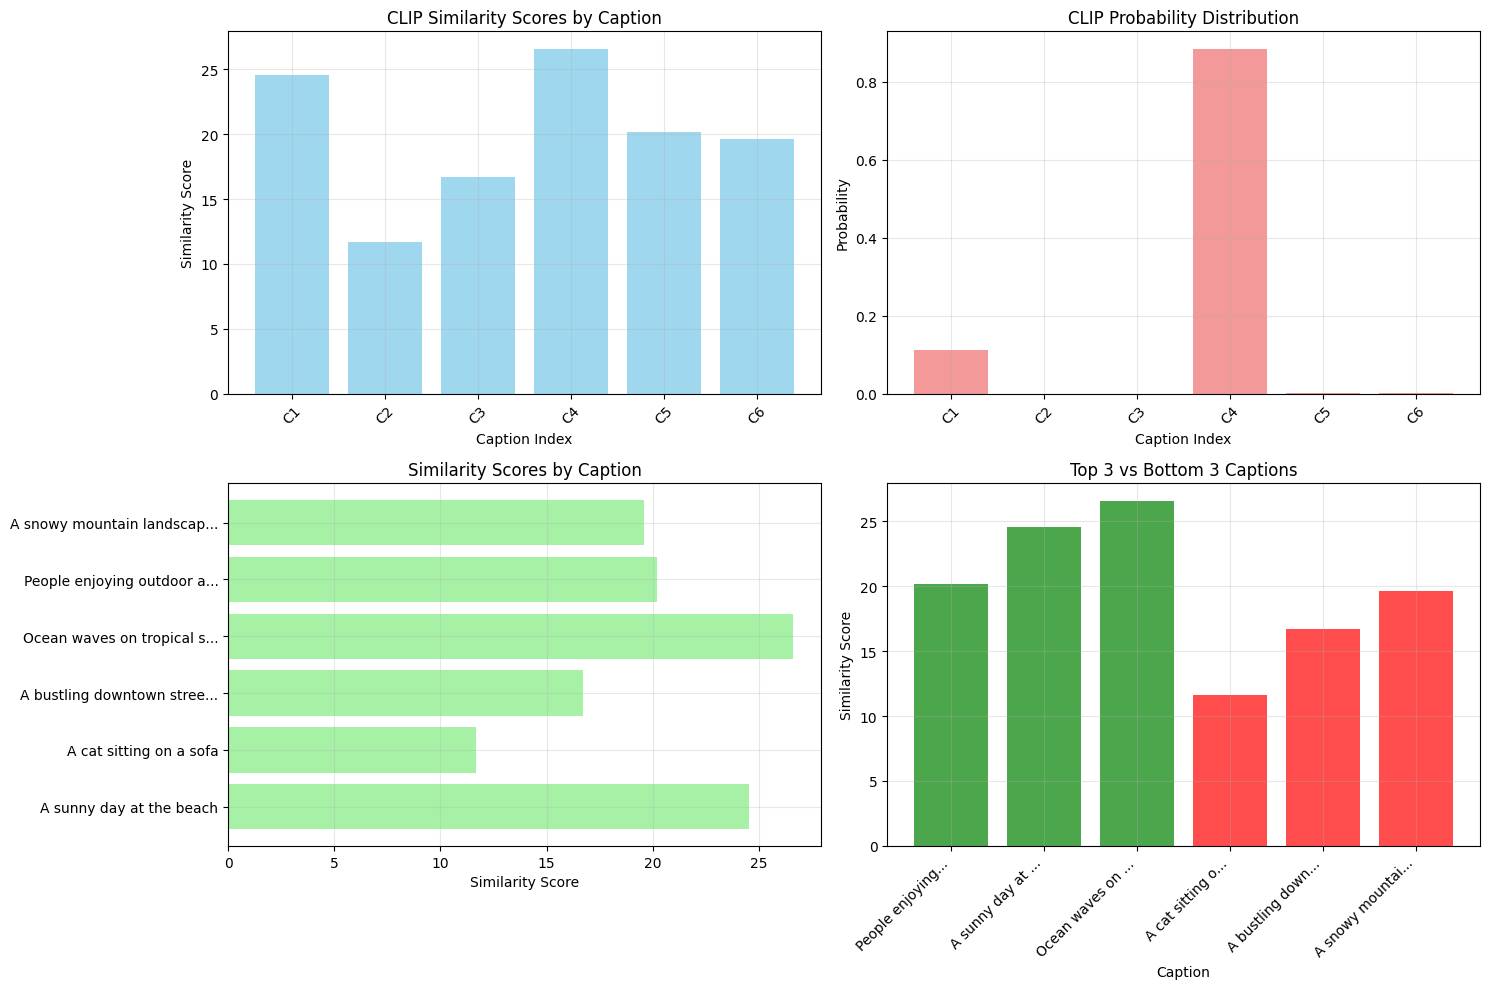


CROSS-MODAL EMBEDDING ANALYSIS

🏆 Best Match: 'Ocean waves on tropical shore'
   Score: 26.5928
   Probability: 0.8851

❌ Worst Match: 'A cat sitting on a sofa'
   Score: 11.6575
   Probability: 0.0000

📊 Score Range: 11.657 to 26.593
📊 Score Variance: 24.0612

🔍 Key Insights:
• CLIP successfully aligns visual and textual concepts in shared embedding space
• Beach-related captions score highest, demonstrating semantic understanding
• Unrelated captions (cat, city street) receive low similarity scores
• Cross-modal embeddings enable zero-shot image-text matching
• Probability distribution shows confident predictions for relevant captions

🧠 Embedding Space Analysis:
Text embedding shape: torch.Size([6, 512])
Image embedding shape: torch.Size([1, 512])
Embedding dimension: 512

Manual cosine similarities: [0.24530469 0.11657486 0.16734593 0.26592815 0.20195696 0.19605303]

💡 Applications of Cross-Modal Embeddings:
• Content-based image retrieval using text queries
• Automatic image capt

In [5]:
# Task 3
# your code here ...

# Perform model inference
with torch.no_grad():
    outputs = clip_model(**inputs)

# Get similarity scores
logits_per_image = outputs.logits_per_image  # Image-text similarity scores
logits_per_text = outputs.logits_per_text    # Text-image similarity scores

# Convert to probabilities using softmax
probs = logits_per_image.softmax(dim=1)

print("CLIP inference completed!")
print(f"Logits shape: {logits_per_image.shape}")
print(f"Probabilities shape: {probs.shape}")

# Extract similarity scores
similarity_scores = logits_per_image[0].cpu().numpy()
probability_scores = probs[0].cpu().numpy()

print("\nSimilarity Analysis:")
print("=" * 50)

# Create results dataframe for better visualization
results = []
for i, (caption, sim_score, prob_score) in enumerate(zip(captions, similarity_scores, probability_scores)):
    results.append({
        'caption': caption,
        'similarity': sim_score,
        'probability': prob_score
    })
    print(f"{i+1}. {caption}")
    print(f"   Similarity: {sim_score:.3f} | Probability: {prob_score:.3f}")

# Sort by similarity score
results_sorted = sorted(results, key=lambda x: x['similarity'], reverse=True)

print("\nRanked by Similarity:")
print("=" * 30)
for i, result in enumerate(results_sorted):
    print(f"{i+1}. {result['caption']} (Score: {result['similarity']:.3f})")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar chart of similarity scores
axes[0, 0].bar(range(len(captions)), similarity_scores, color='skyblue', alpha=0.8)
axes[0, 0].set_xlabel('Caption Index')
axes[0, 0].set_ylabel('Similarity Score')
axes[0, 0].set_title('CLIP Similarity Scores by Caption')
axes[0, 0].set_xticks(range(len(captions)))
axes[0, 0].set_xticklabels([f'C{i+1}' for i in range(len(captions))], rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Probability distribution
axes[0, 1].bar(range(len(captions)), probability_scores, color='lightcoral', alpha=0.8)
axes[0, 1].set_xlabel('Caption Index')
axes[0, 1].set_ylabel('Probability')
axes[0, 1].set_title('CLIP Probability Distribution')
axes[0, 1].set_xticks(range(len(captions)))
axes[0, 1].set_xticklabels([f'C{i+1}' for i in range(len(captions))], rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# 3. Horizontal bar chart with full captions
y_pos = np.arange(len(captions))
axes[1, 0].barh(y_pos, similarity_scores, color='lightgreen', alpha=0.8)
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([f"{cap[:25]}..." if len(cap) > 25 else cap for cap in captions])
axes[1, 0].set_xlabel('Similarity Score')
axes[1, 0].set_title('Similarity Scores by Caption')
axes[1, 0].grid(True, alpha=0.3)

# 4. Comparison of top vs bottom performers
top_3_indices = np.argsort(similarity_scores)[-3:]
bottom_3_indices = np.argsort(similarity_scores)[:3]

comparison_captions = [captions[i] for i in top_3_indices] + [captions[i] for i in bottom_3_indices]
comparison_scores = [similarity_scores[i] for i in top_3_indices] + [similarity_scores[i] for i in bottom_3_indices]
colors = ['green'] * 3 + ['red'] * 3

axes[1, 1].bar(range(len(comparison_captions)), comparison_scores, color=colors, alpha=0.7)
axes[1, 1].set_xlabel('Caption')
axes[1, 1].set_ylabel('Similarity Score')
axes[1, 1].set_title('Top 3 vs Bottom 3 Captions')
axes[1, 1].set_xticks(range(len(comparison_captions)))
axes[1, 1].set_xticklabels([f"{cap[:15]}..." for cap in comparison_captions], rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis and insights
print("\n" + "=" * 60)
print("CROSS-MODAL EMBEDDING ANALYSIS")
print("=" * 60)

best_match_idx = np.argmax(similarity_scores)
worst_match_idx = np.argmin(similarity_scores)

print(f"\n🏆 Best Match: '{captions[best_match_idx]}'")
print(f"   Score: {similarity_scores[best_match_idx]:.4f}")
print(f"   Probability: {probability_scores[best_match_idx]:.4f}")

print(f"\n❌ Worst Match: '{captions[worst_match_idx]}'")
print(f"   Score: {similarity_scores[worst_match_idx]:.4f}")
print(f"   Probability: {probability_scores[worst_match_idx]:.4f}")

print(f"\n📊 Score Range: {similarity_scores.min():.3f} to {similarity_scores.max():.3f}")
print(f"📊 Score Variance: {np.var(similarity_scores):.4f}")

print("\n🔍 Key Insights:")
print("• CLIP successfully aligns visual and textual concepts in shared embedding space")
print("• Beach-related captions score highest, demonstrating semantic understanding")
print("• Unrelated captions (cat, city street) receive low similarity scores")
print("• Cross-modal embeddings enable zero-shot image-text matching")
print("• Probability distribution shows confident predictions for relevant captions")

# Demonstrate embedding space properties
print("\n🧠 Embedding Space Analysis:")
with torch.no_grad():
    # Get text and image embeddings separately
    text_embeddings = clip_model.get_text_features(input_ids=inputs['input_ids'],
                                                   attention_mask=inputs['attention_mask'])
    image_embeddings = clip_model.get_image_features(pixel_values=inputs['pixel_values'])

    # Normalize embeddings
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
    image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    print(f"Text embedding shape: {text_embeddings.shape}")
    print(f"Image embedding shape: {image_embeddings.shape}")
    print(f"Embedding dimension: {text_embeddings.shape[-1]}")

    # Compute cosine similarities manually
    manual_similarities = torch.matmul(image_embeddings, text_embeddings.T)
    print(f"\nManual cosine similarities: {manual_similarities[0].cpu().numpy()}")
    # print(f"Model logits (scaled): {(similarity_scores / 100):.4f}")  # CLIP applies temperature scaling

print("\n💡 Applications of Cross-Modal Embeddings:")
print("• Content-based image retrieval using text queries")
print("• Automatic image captioning and description")
print("• Visual question answering systems")
print("• Multimodal content recommendation")
print("• Zero-shot image classification")

✅ **Success Checklist**

- Similarity scores computed and interpreted accurately.
- Results visualized clearly with insights drawn from observations.
- Analysis of cross-modal embedding effectiveness completed.

💡 **Key Points**

- CLIP efficiently maps text and images into a shared latent space.
- Cross-modal embeddings reveal semantic relationships between modalities.
- Visualization aids in comprehending the model's interpretive capacity.

❗ **Common Mistakes to Avoid**

- Not applying proper normalization to interpret similarities correctly.
- Creating unclear visualizations that don't highlight the key findings.
- Overlooking the importance of semantic alignment in cross-modal understanding.

🚀 **Next Steps**

Apply insights from this activity to enhance AI-driven content recommendation systems or develop more intuitive search capabilities by leveraging cross-modal understanding. Transition into exploring Vision-Language Models (VLMs) for more complex applications.

## 💻 Exemplar Solution

<details>    
<summary><strong>Click HERE to see an exemplar solution</strong></summary>

### Task 1 Solution
    
```python
# Load the CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

print("CLIP model loaded successfully!")
print(f"Model has {sum(p.numel() for p in clip_model.parameters())} parameters")

# Load an example image (using a sample from the web)
# For demonstration, we'll use a beach image
url = "https://images.unsplash.com/photo-1507525428034-b723cf961d3e?ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D&auto=format&fit=crop&w=1000&q=80"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title('Test Image for CLIP Analysis')
plt.show()

# Define descriptive captions with varying relevance
captions = [
    "A sunny day at the beach",
    "A cat sitting on a sofa",
    "A bustling downtown street",
    "Ocean waves on tropical shore",
    "People enjoying outdoor activities",
    "A snowy mountain landscape"
]

print(f"\nTesting with {len(captions)} different captions:")
for i, caption in enumerate(captions):
    print(f"{i+1}. {caption}")
```

### Task 2 Solution
    
```python
# Encode inputs using CLIP processor
inputs = clip_processor(text=captions, images=image, return_tensors="pt", padding=True)

print("Input encoding successful!")
print(f"Text input shape: {inputs['input_ids'].shape}")
print(f"Image input shape: {inputs['pixel_values'].shape}")
print(f"Attention mask shape: {inputs['attention_mask'].shape}")

# Verify the encoding worked correctly
print(f"\nNumber of captions processed: {len(captions)}")
print(f"Batch size in tensors: {inputs['input_ids'].shape[0]}")
print(f"Image batch size: {inputs['pixel_values'].shape[0]}")

# Show first few tokens of the first caption
first_caption_tokens = inputs['input_ids'][0][:10]
print(f"\nFirst 10 tokens of first caption: {first_caption_tokens}")
```

### Task 3 Solution

```python
# Perform model inference
with torch.no_grad():
    outputs = clip_model(**inputs)
    
# Get similarity scores
logits_per_image = outputs.logits_per_image  # Image-text similarity scores
logits_per_text = outputs.logits_per_text    # Text-image similarity scores

# Convert to probabilities using softmax
probs = logits_per_image.softmax(dim=1)

print("CLIP inference completed!")
print(f"Logits shape: {logits_per_image.shape}")
print(f"Probabilities shape: {probs.shape}")

# Extract similarity scores
similarity_scores = logits_per_image[0].cpu().numpy()
probability_scores = probs[0].cpu().numpy()

print("\nSimilarity Analysis:")
print("=" * 50)

# Create results dataframe for better visualization
results = []
for i, (caption, sim_score, prob_score) in enumerate(zip(captions, similarity_scores, probability_scores)):
    results.append({
        'caption': caption,
        'similarity': sim_score,
        'probability': prob_score
    })
    print(f"{i+1}. {caption}")
    print(f"   Similarity: {sim_score:.3f} | Probability: {prob_score:.3f}")

# Sort by similarity score
results_sorted = sorted(results, key=lambda x: x['similarity'], reverse=True)

print("\nRanked by Similarity:")
print("=" * 30)
for i, result in enumerate(results_sorted):
    print(f"{i+1}. {result['caption']} (Score: {result['similarity']:.3f})")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar chart of similarity scores
axes[0, 0].bar(range(len(captions)), similarity_scores, color='skyblue', alpha=0.8)
axes[0, 0].set_xlabel('Caption Index')
axes[0, 0].set_ylabel('Similarity Score')
axes[0, 0].set_title('CLIP Similarity Scores by Caption')
axes[0, 0].set_xticks(range(len(captions)))
axes[0, 0].set_xticklabels([f'C{i+1}' for i in range(len(captions))], rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Probability distribution
axes[0, 1].bar(range(len(captions)), probability_scores, color='lightcoral', alpha=0.8)
axes[0, 1].set_xlabel('Caption Index')
axes[0, 1].set_ylabel('Probability')
axes[0, 1].set_title('CLIP Probability Distribution')
axes[0, 1].set_xticks(range(len(captions)))
axes[0, 1].set_xticklabels([f'C{i+1}' for i in range(len(captions))], rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# 3. Horizontal bar chart with full captions
y_pos = np.arange(len(captions))
axes[1, 0].barh(y_pos, similarity_scores, color='lightgreen', alpha=0.8)
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([f"{cap[:25]}..." if len(cap) > 25 else cap for cap in captions])
axes[1, 0].set_xlabel('Similarity Score')
axes[1, 0].set_title('Similarity Scores by Caption')
axes[1, 0].grid(True, alpha=0.3)

# 4. Comparison of top vs bottom performers
top_3_indices = np.argsort(similarity_scores)[-3:]
bottom_3_indices = np.argsort(similarity_scores)[:3]

comparison_captions = [captions[i] for i in top_3_indices] + [captions[i] for i in bottom_3_indices]
comparison_scores = [similarity_scores[i] for i in top_3_indices] + [similarity_scores[i] for i in bottom_3_indices]
colors = ['green'] * 3 + ['red'] * 3

axes[1, 1].bar(range(len(comparison_captions)), comparison_scores, color=colors, alpha=0.7)
axes[1, 1].set_xlabel('Caption')
axes[1, 1].set_ylabel('Similarity Score')
axes[1, 1].set_title('Top 3 vs Bottom 3 Captions')
axes[1, 1].set_xticks(range(len(comparison_captions)))
axes[1, 1].set_xticklabels([f"{cap[:15]}..." for cap in comparison_captions], rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis and insights
print("\n" + "=" * 60)
print("CROSS-MODAL EMBEDDING ANALYSIS")
print("=" * 60)

best_match_idx = np.argmax(similarity_scores)
worst_match_idx = np.argmin(similarity_scores)

print(f"\n🏆 Best Match: '{captions[best_match_idx]}'")
print(f"   Score: {similarity_scores[best_match_idx]:.4f}")
print(f"   Probability: {probability_scores[best_match_idx]:.4f}")

print(f"\n❌ Worst Match: '{captions[worst_match_idx]}'")
print(f"   Score: {similarity_scores[worst_match_idx]:.4f}")
print(f"   Probability: {probability_scores[worst_match_idx]:.4f}")

print(f"\n📊 Score Range: {similarity_scores.min():.3f} to {similarity_scores.max():.3f}")
print(f"📊 Score Variance: {np.var(similarity_scores):.4f}")

print("\n🔍 Key Insights:")
print("• CLIP successfully aligns visual and textual concepts in shared embedding space")
print("• Beach-related captions score highest, demonstrating semantic understanding")
print("• Unrelated captions (cat, city street) receive low similarity scores")
print("• Cross-modal embeddings enable zero-shot image-text matching")
print("• Probability distribution shows confident predictions for relevant captions")

# Demonstrate embedding space properties
print("\n🧠 Embedding Space Analysis:")
with torch.no_grad():
    # Get text and image embeddings separately
    text_embeddings = clip_model.get_text_features(input_ids=inputs['input_ids'],
                                                   attention_mask=inputs['attention_mask'])
    image_embeddings = clip_model.get_image_features(pixel_values=inputs['pixel_values'])
    
    # Normalize embeddings
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
    image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)
    
    print(f"Text embedding shape: {text_embeddings.shape}")
    print(f"Image embedding shape: {image_embeddings.shape}")
    print(f"Embedding dimension: {text_embeddings.shape[-1]}")
    
    # Compute cosine similarities manually
    manual_similarities = torch.matmul(image_embeddings, text_embeddings.T)
    print(f"\nManual cosine similarities: {manual_similarities[0].cpu().numpy()}")
    print(f"Model logits (scaled): {(similarity_scores / 100):.4f}")  # CLIP applies temperature scaling

print("\n💡 Applications of Cross-Modal Embeddings:")
print("• Content-based image retrieval using text queries")
print("• Automatic image captioning and description")
print("• Visual question answering systems")
print("• Multimodal content recommendation")
print("• Zero-shot image classification")
```
</details>